# 1 2

In [1]:
from pathlib import Path
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 3

In [2]:
CHECKPOINT_PATH = Path(r"C:\Users\Hoannd\Downloads\data_face\vfa_work\project_checkpoint_state.json")

print("Checkpoint exists:", CHECKPOINT_PATH.exists())
print("Checkpoint path:", CHECKPOINT_PATH)

with open(CHECKPOINT_PATH, "r", encoding="utf-8") as f:
    state = json.load(f)

state

Checkpoint exists: True
Checkpoint path: C:\Users\Hoannd\Downloads\data_face\vfa_work\project_checkpoint_state.json


{'created_at': '2026-05-12 18:11:27',
 'base_dir': 'C:\\Users\\Hoannd\\Downloads\\data_face',
 'processed_dir': 'C:\\Users\\Hoannd\\Downloads\\data_face\\processed_vfa',
 'face_crop_dir': 'C:\\Users\\Hoannd\\Downloads\\data_face\\processed_vfa_face_crop',
 'out_dir': 'C:\\Users\\Hoannd\\Downloads\\data_face\\vfa_work',
 'model_dir': 'C:\\Users\\Hoannd\\Downloads\\data_face\\models',
 'split_metadata': 'C:\\Users\\Hoannd\\Downloads\\data_face\\vfa_work\\vfa_split_metadata.csv',
 'crop_metadata': 'C:\\Users\\Hoannd\\Downloads\\data_face\\vfa_work\\vfa_face_crop_metadata.csv',
 'best_model': 'C:\\Users\\Hoannd\\Downloads\\data_face\\models\\vfa_mobilenetv3_small_best.pth',
 'deploy_config': 'C:\\Users\\Hoannd\\Downloads\\data_face\\models\\vfa_deploy_config.json',
 'note': 'Continue from this checkpoint. Do not rerun raw scan/copy/crop unless needed.'}

# 4

In [3]:
BASE_DIR = Path(state["base_dir"])
OUT_DIR = Path(state["out_dir"])
MODEL_DIR = Path(state["model_dir"])

VERIFY_DIR = BASE_DIR / "face_verification_poc"
VERIFY_DIR.mkdir(parents=True, exist_ok=True)

ENROLL_DIR = VERIFY_DIR / "enroll"
QUERY_DIR = VERIFY_DIR / "query"
PAIR_DIR = VERIFY_DIR / "pairs"

for d in [ENROLL_DIR, QUERY_DIR, PAIR_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("VERIFY_DIR:", VERIFY_DIR)
print("ENROLL_DIR:", ENROLL_DIR)
print("QUERY_DIR:", QUERY_DIR)
print("PAIR_DIR:", PAIR_DIR)

BASE_DIR: C:\Users\Hoannd\Downloads\data_face
VERIFY_DIR: C:\Users\Hoannd\Downloads\data_face\face_verification_poc
ENROLL_DIR: C:\Users\Hoannd\Downloads\data_face\face_verification_poc\enroll
QUERY_DIR: C:\Users\Hoannd\Downloads\data_face\face_verification_poc\query
PAIR_DIR: C:\Users\Hoannd\Downloads\data_face\face_verification_poc\pairs


# 5

# Quy ước dữ liệu Face Verification POC

Thư mục dữ liệu:

```text
face_verification_poc/
  enroll/
    person_001/
      001.jpg
      002.jpg
    person_002/
      001.jpg
      002.jpg

  query/
    person_001/
      q001.jpg
      q002.jpg
    person_002/
      q001.jpg
      q002.jpg

# 6

In [4]:
from insightface.app import FaceAnalysis

app = FaceAnalysis(
    name="buffalo_l",
    providers=["CPUExecutionProvider"]
)

app.prepare(ctx_id=0, det_size=(640, 640))

print("InsightFace loaded")

download_path: C:\Users\Hoannd/.insightface\models\buffalo_l


100%|██████████| 281857/281857 [01:03<00:00, 4410.36KB/s] 


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Hoannd/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Hoannd/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Hoannd/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Hoannd/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Hoannd/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112]

# 7

In [9]:
def read_image_bgr(image_path):
    image_path = Path(image_path)
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Cannot read image: {image_path}")
    return img


def get_largest_face(faces):
    if len(faces) == 0:
        return None
    
    def face_area(face):
        x1, y1, x2, y2 = face.bbox
        return max(0, x2 - x1) * max(0, y2 - y1)
    
    return max(faces, key=face_area)


def extract_face_embedding(image_path):
    img_bgr = read_image_bgr(image_path)
    faces = app.get(img_bgr)
    
    face = get_largest_face(faces)
    
    if face is None:
        return None, {
            "ok": False,
            "reason": "no_face",
            "bbox": None
        }
    
    emb = face.embedding.astype(np.float32)
    
    # normalize embedding
    emb = emb / np.linalg.norm(emb)
    
    info = {
        "ok": True,
        "reason": "ok",
        "bbox": face.bbox.tolist(),
        "det_score": float(face.det_score)
    }
    
    return emb, info

# 8

In [11]:
def show_face_detection(image_path):
    img_bgr = read_image_bgr(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    faces = app.get(img_bgr)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    
    ax = plt.gca()
    
    for face in faces:
        x1, y1, x2, y2 = face.bbox
        rect = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2
        )
        ax.add_patch(rect)
        ax.text(x1, y1, f"{face.det_score:.2f}")
    
    plt.axis("off")
    plt.title(f"faces detected: {len(faces)}")
    plt.show()

# 9

In [12]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def scan_person_images(root_dir):
    root_dir = Path(root_dir)
    records = []
    
    for person_dir in root_dir.iterdir():
        if not person_dir.is_dir():
            continue
        
        person_id = person_dir.name
        
        for img_path in person_dir.rglob("*"):
            if img_path.suffix.lower() in IMAGE_EXTS:
                records.append({
                    "person_id": person_id,
                    "path": str(img_path),
                    "filename": img_path.name
                })
    
    return pd.DataFrame(records)


df_enroll = scan_person_images(ENROLL_DIR)
df_query = scan_person_images(QUERY_DIR)

print("Enroll images:", len(df_enroll))
display(df_enroll.head())

print("Query images:", len(df_query))
display(df_query.head())

Enroll images: 6


,person_id,path,filename
0,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,1.jpg
1,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,2.jpg
2,person_002,C:\Users\Hoannd\Downloads\data_face\face_verif...,1.jpg
3,person_002,C:\Users\Hoannd\Downloads\data_face\face_verif...,2.jpg
4,person_003,C:\Users\Hoannd\Downloads\data_face\face_verif...,1.jpg


Query images: 15


,person_id,path,filename
0,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,1.jpg
1,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,2.jpg
2,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,3.jpg
3,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,4.jpg
4,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,5.jpg


# 10

C:\Users\Hoannd\Downloads\data_face\face_verification_poc\enroll\person_001\1.jpg


c:\Users\Hoannd\AppData\Local\Programs\Python\Python312\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


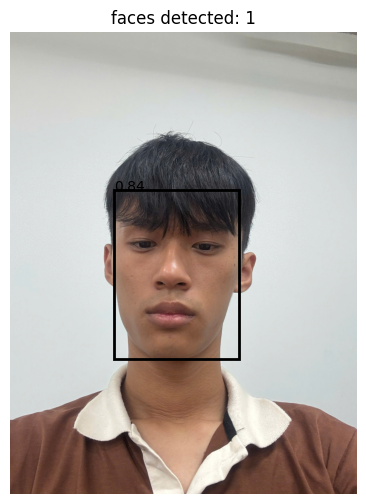

In [13]:
sample_img = df_enroll.iloc[0]["path"]

print(sample_img)
show_face_detection(sample_img)

# 11

In [14]:
enroll_records = []

for row in tqdm(df_enroll.itertuples(), total=len(df_enroll), desc="Extract enroll embeddings"):
    emb, info = extract_face_embedding(row.path)
    
    enroll_records.append({
        "person_id": row.person_id,
        "path": row.path,
        "ok": info["ok"],
        "reason": info["reason"],
        "det_score": info.get("det_score", None),
        "embedding": emb
    })

df_enroll_emb = pd.DataFrame(enroll_records)

display(df_enroll_emb[["person_id", "path", "ok", "reason", "det_score"]])
display(df_enroll_emb["reason"].value_counts())

Extract enroll embeddings: 100%|██████████| 6/6 [00:01<00:00,  4.65it/s]


,person_id,path,ok,reason,det_score
0,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,True,ok,0.835393
1,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,True,ok,0.858847
2,person_002,C:\Users\Hoannd\Downloads\data_face\face_verif...,True,ok,0.727306
3,person_002,C:\Users\Hoannd\Downloads\data_face\face_verif...,True,ok,0.849890
4,person_003,C:\Users\Hoannd\Downloads\data_face\face_verif...,True,ok,0.883118
5,person_003,C:\Users\Hoannd\Downloads\data_face\face_verif...,True,ok,0.857756


reason
ok    6
Name: count, dtype: int64

# 12

In [15]:
query_records = []

for row in tqdm(df_query.itertuples(), total=len(df_query), desc="Extract query embeddings"):
    emb, info = extract_face_embedding(row.path)
    
    query_records.append({
        "person_id": row.person_id,
        "path": row.path,
        "ok": info["ok"],
        "reason": info["reason"],
        "det_score": info.get("det_score", None),
        "embedding": emb
    })

df_query_emb = pd.DataFrame(query_records)

display(df_query_emb[["person_id", "path", "ok", "reason", "det_score"]])
display(df_query_emb["reason"].value_counts())

Extract query embeddings:   0%|          | 0/15 [00:00<?, ?it/s]c:\Users\Hoannd\AppData\Local\Programs\Python\Python312\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
Extract query embeddings: 100%|██████████| 15/15 [00:02<00:00,  5.03it/s]


,person_id,path,ok,reason,det_score
0,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,True,ok,0.894600
1,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,True,ok,0.901980
2,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,True,ok,0.855878
3,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,True,ok,0.816466
4,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,True,ok,0.774725
5,person_002,C:\Users\Hoannd\Downloads\data_face\face_verif...,True,ok,0.860234
6,person_002,C:\Users\Hoannd\Downloads\data_face\face_verif...,True,ok,0.773166
7,person_002,C:\Users\Hoannd\Downloads\data_face\face_verif...,True,ok,0.835070
8,person_002,C:\Users\Hoannd\Downloads\data_face\face_verif...,True,ok,0.705293
9,person_002,C:\Users\Hoannd\Downloads\data_face\face_verif...,True,ok,0.819591


reason
ok    15
Name: count, dtype: int64

# 13

In [16]:
person_templates = {}

df_enroll_ok = df_enroll_emb[df_enroll_emb["ok"] == True].copy()

for person_id, group in df_enroll_ok.groupby("person_id"):
    embs = np.stack(group["embedding"].values)
    
    template = embs.mean(axis=0)
    template = template / np.linalg.norm(template)
    
    person_templates[person_id] = template

print("Số người có template:", len(person_templates))
print(list(person_templates.keys()))

Số người có template: 3
['person_001', 'person_002', 'person_003']


# 14

In [17]:
verify_records = []

df_query_ok = df_query_emb[df_query_emb["ok"] == True].copy()

for row in df_query_ok.itertuples():
    query_person = row.person_id
    query_emb = row.embedding
    
    if query_person not in person_templates:
        continue
    
    enroll_template = person_templates[query_person]
    
    sim = float(np.dot(query_emb, enroll_template))
    
    verify_records.append({
        "query_person": query_person,
        "query_path": row.path,
        "enroll_person": query_person,
        "same_person": True,
        "similarity": sim
    })

df_verify_positive = pd.DataFrame(verify_records)

display(df_verify_positive)
display(df_verify_positive["similarity"].describe())

,query_person,query_path,enroll_person,same_person,similarity
0,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_001,True,0.895061
1,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_001,True,0.838115
2,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_001,True,0.900216
3,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_001,True,0.858843
4,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_001,True,0.889012
5,person_002,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_002,True,0.811491
6,person_002,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_002,True,0.903427
7,person_002,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_002,True,0.875966
8,person_002,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_002,True,0.910527
9,person_002,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_002,True,0.815128


count    15.000000
mean      0.887534
std       0.041452
min       0.811491
25%       0.867405
50%       0.898947
75%       0.906977
max       0.952009
Name: similarity, dtype: float64

# 15

In [18]:
negative_records = []

person_ids = list(person_templates.keys())

for row in df_query_ok.itertuples():
    query_person = row.person_id
    query_emb = row.embedding
    
    for enroll_person in person_ids:
        if enroll_person == query_person:
            continue
        
        enroll_template = person_templates[enroll_person]
        sim = float(np.dot(query_emb, enroll_template))
        
        negative_records.append({
            "query_person": query_person,
            "query_path": row.path,
            "enroll_person": enroll_person,
            "same_person": False,
            "similarity": sim
        })

df_verify_negative = pd.DataFrame(negative_records)

display(df_verify_negative.head())
display(df_verify_negative["similarity"].describe())

,query_person,query_path,enroll_person,same_person,similarity
0,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_002,False,0.152451
1,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_003,False,0.088116
2,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_002,False,0.139970
3,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_003,False,0.039131
4,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_002,False,0.177170


count    30.000000
mean      0.105568
std       0.049697
min       0.039131
25%       0.063929
50%       0.082250
75%       0.148936
max       0.198606
Name: similarity, dtype: float64

# 16

In [19]:
df_pairs = pd.concat(
    [df_verify_positive, df_verify_negative],
    ignore_index=True
)

df_pairs["label"] = df_pairs["same_person"].astype(int)

print("Tổng số pair:", len(df_pairs))
display(df_pairs["same_person"].value_counts())
display(df_pairs.head())

Tổng số pair: 45


same_person
False    30
True     15
Name: count, dtype: int64

,query_person,query_path,enroll_person,same_person,similarity,label
0,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_001,True,0.895061,1
1,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_001,True,0.838115,1
2,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_001,True,0.900216,1
3,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_001,True,0.858843,1
4,person_001,C:\Users\Hoannd\Downloads\data_face\face_verif...,person_001,True,0.889012,1


# 17

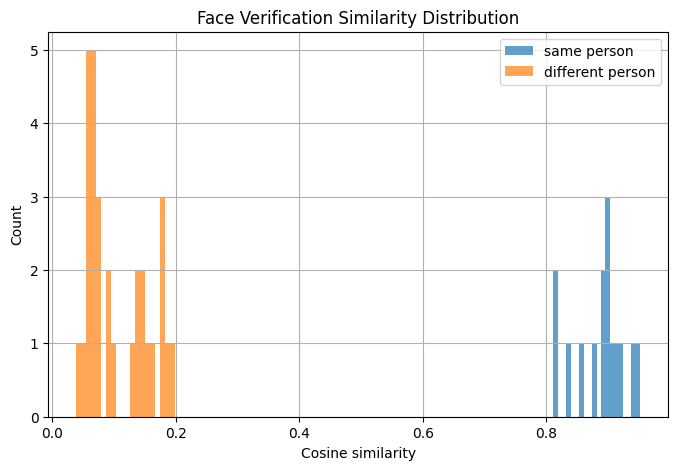

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_pairs[df_pairs["same_person"] == True]["similarity"],
    bins=20,
    alpha=0.7,
    label="same person"
)

plt.hist(
    df_pairs[df_pairs["same_person"] == False]["similarity"],
    bins=20,
    alpha=0.7,
    label="different person"
)

plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.title("Face Verification Similarity Distribution")
plt.legend()
plt.grid(True)
plt.show()

# 18

In [21]:
thresholds = np.arange(0.0, 1.01, 0.01)

rows = []

y_true = df_pairs["label"].values

for th in thresholds:
    y_pred = (df_pairs["similarity"].values >= th).astype(int)
    
    acc = accuracy_score(y_true, y_pred)
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    rows.append({
        "threshold": round(float(th), 2),
        "accuracy": acc,
        "TP_same_accept": tp,
        "TN_diff_reject": tn,
        "FP_diff_accept_BAD": fp,
        "FN_same_reject": fn
    })

df_th = pd.DataFrame(rows)

display(df_th.sort_values("accuracy", ascending=False).head(20))

,threshold,accuracy,TP_same_accept,TN_diff_reject,FP_diff_accept_BAD,FN_same_reject
32,0.32,1.0,15,30,0,0
33,0.33,1.0,15,30,0,0
34,0.34,1.0,15,30,0,0
35,0.35,1.0,15,30,0,0
20,0.20,1.0,15,30,0,0
36,0.36,1.0,15,30,0,0
27,0.27,1.0,15,30,0,0
26,0.26,1.0,15,30,0,0
25,0.25,1.0,15,30,0,0
24,0.24,1.0,15,30,0,0


# 19

In [22]:
best_row = df_th.sort_values(
    ["FP_diff_accept_BAD", "accuracy"],
    ascending=[True, False]
).iloc[0]

VERIFY_THRESHOLD = float(best_row["threshold"])

print("Selected VERIFY_THRESHOLD:", VERIFY_THRESHOLD)
display(best_row)

Selected VERIFY_THRESHOLD: 0.2


threshold              0.2
accuracy               1.0
TP_same_accept        15.0
TN_diff_reject        30.0
FP_diff_accept_BAD     0.0
FN_same_reject         0.0
Name: 20, dtype: float64

# 20

In [23]:
y_true = df_pairs["label"].values
y_pred = (df_pairs["similarity"].values >= VERIFY_THRESHOLD).astype(int)

print("VERIFY_THRESHOLD:", VERIFY_THRESHOLD)

print(classification_report(
    y_true,
    y_pred,
    target_names=["different_person", "same_person"],
    digits=4
))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index=["true_different", "true_same"],
    columns=["pred_different", "pred_same"]
)

display(cm_df)

VERIFY_THRESHOLD: 0.2
                  precision    recall  f1-score   support

different_person     1.0000    1.0000    1.0000        30
     same_person     1.0000    1.0000    1.0000        15

        accuracy                         1.0000        45
       macro avg     1.0000    1.0000    1.0000        45
    weighted avg     1.0000    1.0000    1.0000        45



,pred_different,pred_same
true_different,30,0
true_same,0,15


# 21

In [24]:
VERIFY_THRESHOLD = 0.35

print("Final VERIFY_THRESHOLD:", VERIFY_THRESHOLD)

Final VERIFY_THRESHOLD: 0.35


# 22

In [25]:
y_true = df_pairs["label"].values
y_pred = (df_pairs["similarity"].values >= VERIFY_THRESHOLD).astype(int)

print("VERIFY_THRESHOLD:", VERIFY_THRESHOLD)

print(classification_report(
    y_true,
    y_pred,
    target_names=["different_person", "same_person"],
    digits=4
))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index=["true_different", "true_same"],
    columns=["pred_different", "pred_same"]
)

display(cm_df)

VERIFY_THRESHOLD: 0.35
                  precision    recall  f1-score   support

different_person     1.0000    1.0000    1.0000        30
     same_person     1.0000    1.0000    1.0000        15

        accuracy                         1.0000        45
       macro avg     1.0000    1.0000    1.0000        45
    weighted avg     1.0000    1.0000    1.0000        45



,pred_different,pred_same
true_different,30,0
true_same,0,15


# 23

In [26]:
import pickle

templates_path = VERIFY_DIR / "person_templates.pkl"

with open(templates_path, "wb") as f:
    pickle.dump(person_templates, f)

print("Saved templates:", templates_path)
print("Persons:", list(person_templates.keys()))

Saved templates: C:\Users\Hoannd\Downloads\data_face\face_verification_poc\person_templates.pkl
Persons: ['person_001', 'person_002', 'person_003']


# 24

In [27]:
verify_config = {
    "module": "face_verification_1_to_1",
    "model": "InsightFace buffalo_l",
    "method": "ArcFace embedding + cosine similarity",
    "verify_threshold": VERIFY_THRESHOLD,
    "num_persons": len(person_templates),
    "num_positive_pairs": int((df_pairs["same_person"] == True).sum()),
    "num_negative_pairs": int((df_pairs["same_person"] == False).sum()),
    "poc_accuracy": float(accuracy_score(y_true, y_pred)),
    "templates_path": str(templates_path),
    "note": "POC threshold selected from small local sample. For production, validate on larger identity dataset."
}

verify_config_path = VERIFY_DIR / "face_verification_config.json"

with open(verify_config_path, "w", encoding="utf-8") as f:
    json.dump(verify_config, f, ensure_ascii=False, indent=2)

print("Saved config:", verify_config_path)
verify_config

Saved config: C:\Users\Hoannd\Downloads\data_face\face_verification_poc\face_verification_config.json


{'module': 'face_verification_1_to_1',
 'model': 'InsightFace buffalo_l',
 'method': 'ArcFace embedding + cosine similarity',
 'verify_threshold': 0.35,
 'num_persons': 3,
 'num_positive_pairs': 15,
 'num_negative_pairs': 30,
 'poc_accuracy': 1.0,
 'templates_path': 'C:\\Users\\Hoannd\\Downloads\\data_face\\face_verification_poc\\person_templates.pkl',
 'note': 'POC threshold selected from small local sample. For production, validate on larger identity dataset.'}

# 25

In [28]:
def verify_image_against_person(query_image_path, enroll_person_id, threshold=VERIFY_THRESHOLD):
    if enroll_person_id not in person_templates:
        return {
            "ok": False,
            "reason": "unknown_enroll_person",
            "enroll_person_id": enroll_person_id
        }
    
    query_emb, info = extract_face_embedding(query_image_path)
    
    if not info["ok"]:
        return {
            "ok": False,
            "reason": info["reason"],
            "query_image_path": str(query_image_path),
            "enroll_person_id": enroll_person_id
        }
    
    template = person_templates[enroll_person_id]
    similarity = float(np.dot(query_emb, template))
    
    is_same = similarity >= threshold
    
    return {
        "ok": True,
        "query_image_path": str(query_image_path),
        "enroll_person_id": enroll_person_id,
        "similarity": similarity,
        "threshold": threshold,
        "is_same_person": bool(is_same),
        "result": "SAME_PERSON" if is_same else "DIFFERENT_PERSON"
    }

# 26

In [29]:
test_query_path = df_query.iloc[0]["path"]
test_person_id = df_query.iloc[0]["person_id"]

result = verify_image_against_person(
    test_query_path,
    test_person_id,
    threshold=VERIFY_THRESHOLD
)

result

c:\Users\Hoannd\AppData\Local\Programs\Python\Python312\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


{'ok': True,
 'query_image_path': 'C:\\Users\\Hoannd\\Downloads\\data_face\\face_verification_poc\\query\\person_001\\1.jpg',
 'enroll_person_id': 'person_001',
 'similarity': 0.895060658454895,
 'threshold': 0.35,
 'is_same_person': True,
 'result': 'SAME_PERSON'}